In [ ]:
import sys
from pathlib import Path
import importlib
import pandas as pd
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))
from Utility import IdSep
from Utility import Plot
import matplotlib.pyplot as plt

In [79]:
data_path = ROOT / "data" / "EOLENS_2_6.csv"
df = pd.read_csv(data_path)

# Plot composante classique

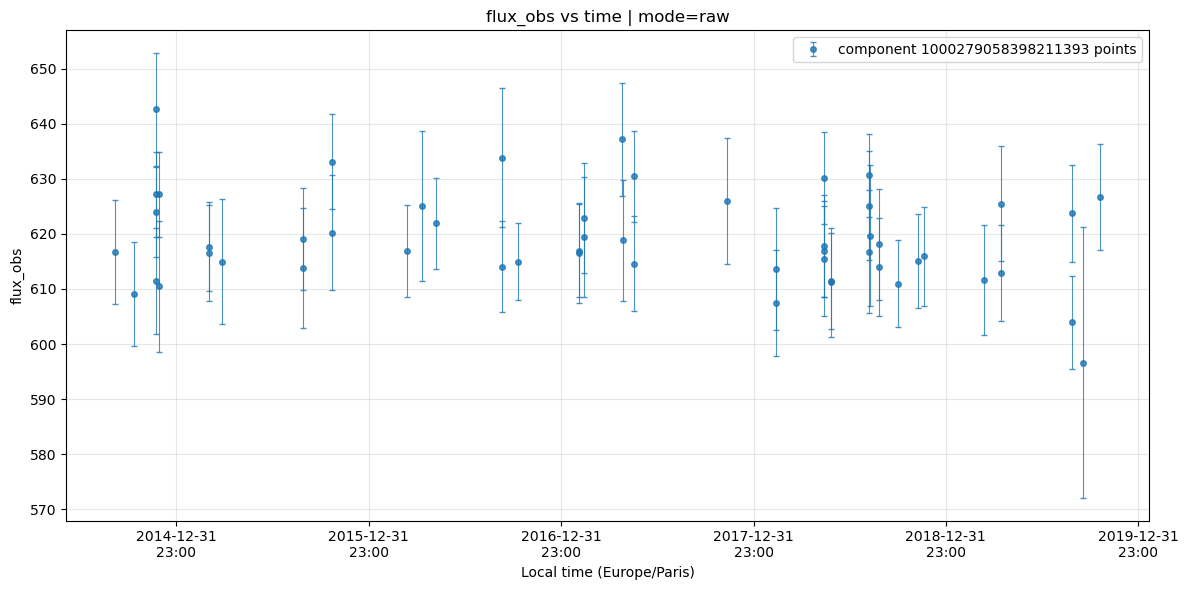

In [82]:
components = Plot.list_lens_components(data_path)
components[:10]
fig, ax = Plot.plot_lens_components_matplotlib(
    data_path,
    lens_component_ids=components[0],
    y_col="flux_obs",
    yerr_col="flux_obs_error",
    y_mode="raw",
    show_points=True,
    show_smooth=False,
    show_gp=False,
)

plt.show()

# Plot composante + Time Delay

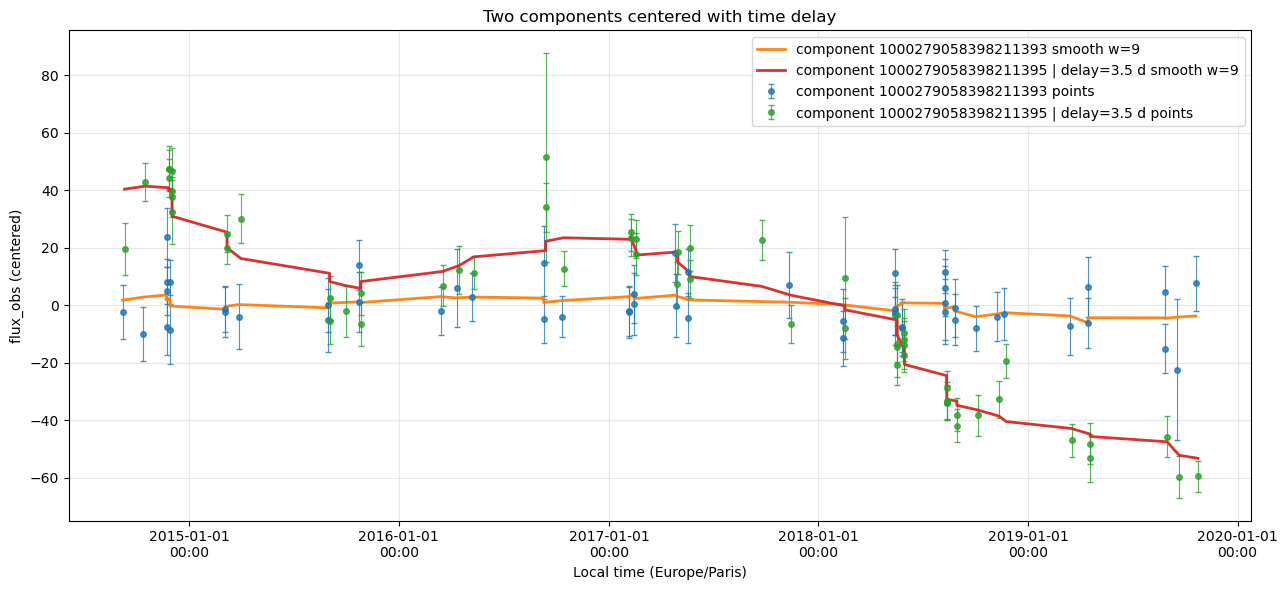

In [97]:
id1 = components[0]
id2 = components[1]

fig, ax = Plot.plot_lens_components_matplotlib(
    data_path,
    lens_component_ids=[id1, id2],
    y_col="flux_obs",
    yerr_col="flux_obs_error",

    y_mode="centered",

    show_points=True,
    show_smooth=True,
    show_gp=False,

    smooth_window=9,

    time_delay_by_component={
        str(id1): 0.0,
        str(id2): 3.5,   # delay in days
    },

    figsize=(13, 6),
    title="Two components centered with time delay",
)

plt.show()

# Plot avec Gaussian Process

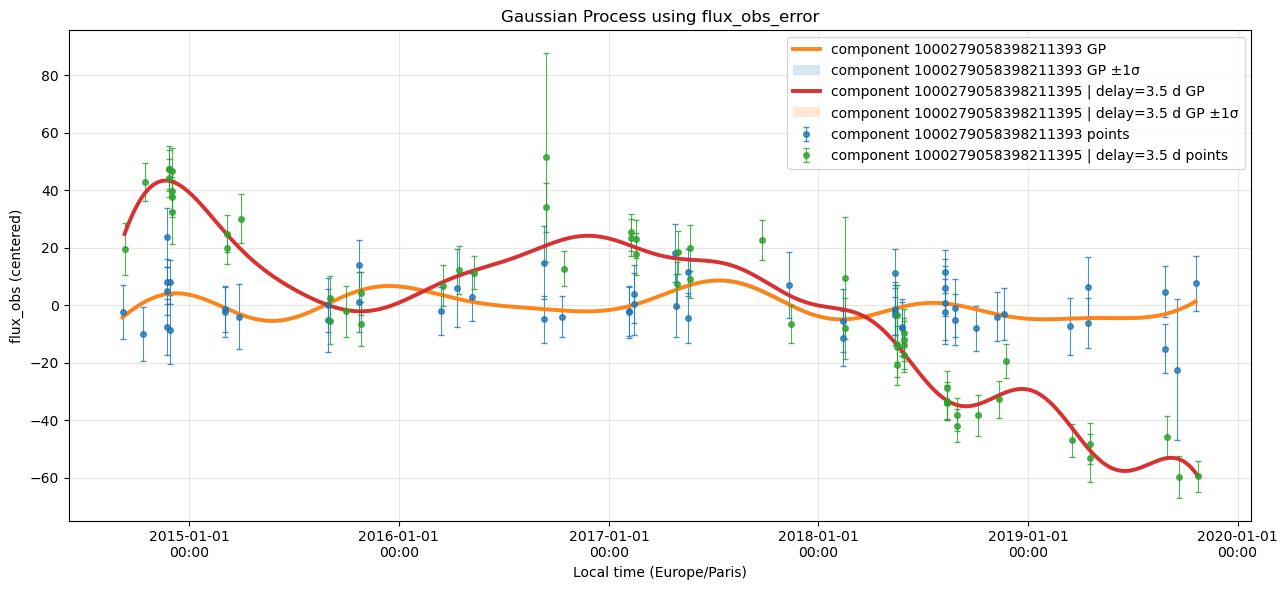

In [98]:
fig, ax = Plot.plot_lens_components_gp(
    data_path,
    lens_component_ids=[id1, id2],

    y_col="flux_obs",
    yerr_col="flux_obs_error",
    y_mode="centered",

    time_delay_by_component={
        str(id1): 0.0,
        str(id2): 3.5,
    },

    gp_length_scale_days=180.0,
    gp_error_scale=0.1,
    gp_show_uncertainty=True,
    gp_fixed_kernel=True,

    figsize=(13, 6),
    title="Gaussian Process using flux_obs_error",
)

plt.show()